In [93]:
import json
import argparse
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import math
import time
import datetime
import numpy as np
import IPython.display as display
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from typing import Tuple, Union, Optional, List
from tqdm.notebook import tqdm
import torch.optim as optim
import dataclasses
import matplotlib.patches as patches
import matplotlib.ticker as ticker
import os
import sys
import warnings
import importlib

In [94]:
file=np.load('/gdata/projects/ml_scope/Turbulence/QG_V0001/Results/Run00003/vorticity_Run00003.npy')

In [95]:
file.shape

(512, 512, 2)

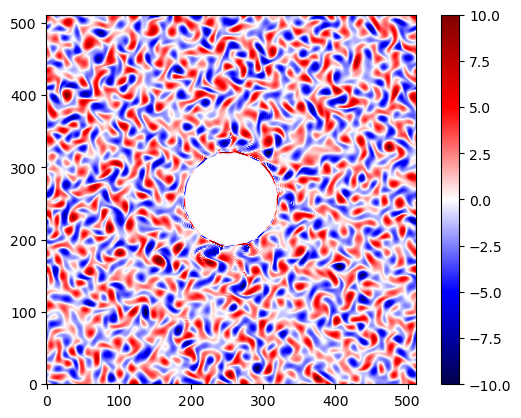

In [98]:
plt.imshow(file[:,:,1], cmap='seismic',origin='lower',vmax=10,vmin=-10)
plt.colorbar()



In [111]:
def vorticity_plots(field,timestep):
    fig, ax = plt.subplots()  # Create a figure and axis

    cax = ax.imshow(field[:, :, timestep], cmap='seismic', origin='lower', vmax=10, vmin=-10, 
                    extent=[0, 2*np.pi, 0, 2*np.pi])  # Set extent for correct scaling

    # Add color bar
    plt.colorbar(cax, ax=ax)

    # Set tick positions and labels in terms of π
    tick_positions = np.linspace(0, 2*np.pi, 3)  # Creates ticks at 0, π, 2π
    tick_labels = [r"$0$", r"$\pi$", r"$2\pi$"]
    ax.set_xticks(tick_positions)
    ax.set_yticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_yticklabels(tick_labels)

    # Set title
    ax.set_title(f"$\omega$ at timestep: {timestep} x1000 dt")

    return fig, ax  # Return the figure and axis objects

(<Figure size 640x480 with 2 Axes>,
 <AxesSubplot:title={'center':'$\\omega$ at timestep: 1 x1000 dt'}>)

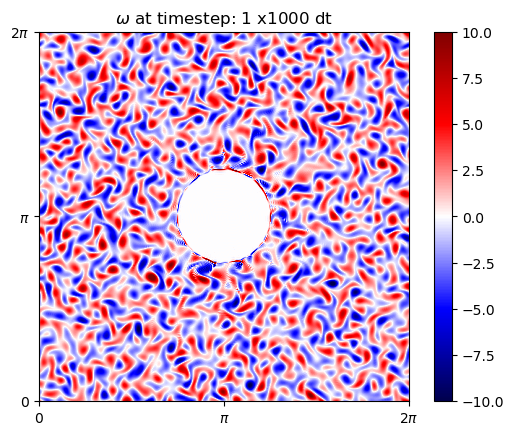

In [113]:
vorticity_plots(file,1)